# **Laboratorio 7 - NLP end-to-end y Embeddings**

CC3092 - Deep Learning y Sistemas Inteligentes

Integrantes: Bryan Martínez 23542 y Adriana Palacios 23044

## **Configuración**

In [27]:
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 123
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

DIR_DATOS = Path("datos")
DIR_MODELOS = Path("modelos")
DIR_RESULTADOS = Path("resultados")
DIR_FIGURAS = Path("figuras")
for directorio in (DIR_DATOS, DIR_MODELOS, DIR_RESULTADOS, DIR_FIGURAS):
    directorio.mkdir(exist_ok=True)

# Pipeline de preprocesamiento (sección 2)
TOKENS_SUBCONJUNTO = 20_000_000
MIN_COUNT = 5
UMBRAL_SUBMUESTREO = 1e-3
VENTANA = 5

# Entrenamiento de SGNS (sección 4)
DIM_BASE = 100
NEGATIVOS = 5
EPOCHS = 5
BATCH_SIZE = 32_768
LEARNING_RATE = 2e-3
PASOS_REGISTRO = 100
VOCAB_EVALUACION = 30_000
PALABRAS_CONTROL = ["king", "france", "computer", "good", "january", "run"]

def fijar_semilla(seed=SEED):
    """Fija la semilla global para reproducibilidad."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

fijar_semilla()
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Dispositivo: mps
PyTorch: 2.14.0


---
# **1. Datos**

En esta sección se cargan los cuatro recursos del laboratorio: el corpus de texto crudo con el que se entrenarán los embeddings propios (WikiText-103), el dataset de clasificación donde se usarán en una tarea real (AG News), el modelo preentrenado de referencia (GloVe de 100 dimensiones) y los benchmarks de evaluación incluidos en gensim. Los datasets de Hugging Face y GloVe se descargan dentro de `datos/`, que está excluido del repositorio.

In [2]:
import os

from datasets import load_dataset

DIR_CACHE_HF = DIR_DATOS / "huggingface"
os.environ.setdefault("GENSIM_DATA_DIR", str((DIR_DATOS / "gensim-data").resolve()))

import gensim.downloader as api
from gensim.test.utils import datapath

## **Corpus: WikiText-103**

In [3]:
corpus = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", cache_dir=DIR_CACHE_HF)
corpus

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-103-raw-v1/test-00000-of-00001.(…): downloading bytes:           |  0.00B            

wikitext-103-raw-v1/train-00000-of-00002(…): reconstructing file:   0%|          |  0.00B /  157MB            

wikitext-103-raw-v1/train-00000-of-00002(…): downloading bytes:           |  0.00B            

...

wikitext-103-raw-v1/validation-00000-of-(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

In [4]:
# Se usa repr para que se vean los saltos de línea y las líneas vacías tal como vienen en el corpus
for i, linea in enumerate(corpus["train"][:12]["text"]):
    print(f"{i}: {linea[:160]!r}")

0: ''
1: ' = Valkyria Chronicles III = \n'
2: ''
3: ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III '
4: ' The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the '
5: ' It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an e'
6: ''
7: ' = = Gameplay = = \n'
8: ''
9: ' As with previous Valkyira Chronicles games , Valkyria Chronicles III is a tactical role @-@ playing game where players take control of a military unit and take'
10: " The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles . During missions , players select each unit using a top @-@ d"
11: ' Troops are divided into five classes : Scouts , Shocktroopers , Engineers , 

## **Clasificación: AG News**

In [5]:
news = load_dataset("fancyzhx/ag_news", cache_dir=DIR_CACHE_HF)
NOMBRES_CLASES = news["train"].features["label"].names
print(f"Clases: {NOMBRES_CLASES}")
news

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Clases: ['World', 'Sports', 'Business', 'Sci/Tech']


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [6]:
pd.set_option("display.max_colwidth", 220)

muestra_news = news["train"].to_pandas().groupby("label").head(2).sort_values("label")
muestra_news["clase"] = muestra_news["label"].map(lambda i: NOMBRES_CLASES[i])
muestra_news[["clase", "text"]].reset_index(drop=True)

,clase,text
0,World,Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Ch...
1,World,"S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used water cannon in\central Seoul Sunday to disperse at least 7,000 protesters\urging the government to reverse a controvers..."
2,Sports,"Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evenin..."
3,Sports,"Reds Knock Padres Out of Wild-Card Lead (AP) AP - Wily Mo Pena homered twice and drove in four runs, helping the Cincinnati Reds beat the San Diego Padres 11-5 on Saturday night. San Diego was knocked out of a share ..."
4,Business,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
5,Business,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quie..."
6,Sci/Tech,"'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because ""Madden NFL 2005"" came out tha..."
7,Sci/Tech,"Group to Propose New High-Speed Wireless Format (Reuters) Reuters - A group of technology companies\including Texas Instruments Inc. (TXN.N), STMicroelectronics\(STM.PA) and Broadcom Corp. (BRCM.O), on Thursday said ..."


## **Modelo preentrenado: GloVe**

In [7]:
glove = api.load("glove-wiki-gigaword-100")

print(f"Tamaño del vocabulario: {len(glove.key_to_index):,}")
print(f"Dimensión: {glove.vector_size}")
print(f"Primeras 15 palabras (las más frecuentes): {glove.index_to_key[:15]}")
print(f"Primeros 8 valores de vec(king): {np.round(glove['king'][:8], 3)}")
pd.DataFrame(glove.most_similar("king", topn=5), columns=["palabra", "similitud_coseno"])

[==================================================] 100.0% 128.1/128.1MB downloaded
Tamaño del vocabulario: 400,000
Dimensión: 100
Primeras 15 palabras (las más frecuentes): ['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s", 'for', '-', 'that', 'on', 'is']
Primeros 8 valores de vec(king): [-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]


,palabra,similitud_coseno
0,prince,0.768233
1,queen,0.750769
2,son,0.702089
3,brother,0.698578
4,monarch,0.697789


## **Benchmarks de evaluación**

In [8]:
analogias = datapath("questions-words.txt")
wordsim = datapath("wordsim353.tsv")
simlex = datapath("simlex999.txt")

lineas_analogias = Path(analogias).read_text(encoding="utf-8").splitlines()
categorias = [linea[2:] for linea in lineas_analogias if linea.startswith(":")]
print(f"Analogías: {len(lineas_analogias) - len(categorias):,} en {len(categorias)} categorías")
print(f"Categorías: {categorias}")
print(f"Ejemplo: {lineas_analogias[1]} (Athens es a Greece como Baghdad es a Iraq)")

columnas = ["palabra_1", "palabra_2", "puntaje_humano"]
df_wordsim = pd.read_csv(wordsim, sep="\t", comment="#", header=None, names=columnas)
df_simlex = pd.read_csv(simlex, sep="\t", comment="#", header=None, names=columnas)
print(f"Pares WordSim-353: {len(df_wordsim)}")
print(f"Pares SimLex-999: {len(df_simlex)}")

pd.concat({"WordSim-353": df_wordsim.head(4), "SimLex-999": df_simlex.head(4)})

Analogías: 19,544 en 14 categorías
Categorías: ['capital-common-countries', 'capital-world', 'currency', 'city-in-state', 'family', 'gram1-adjective-to-adverb', 'gram2-opposite', 'gram3-comparative', 'gram4-superlative', 'gram5-present-participle', 'gram6-nationality-adjective', 'gram7-past-tense', 'gram8-plural', 'gram9-plural-verbs']
Ejemplo: Athens Greece Baghdad Iraq (Athens es a Greece como Baghdad es a Iraq)
Pares WordSim-353: 353
Pares SimLex-999: 999


palabra_1    palabra_2  puntaje_humano
WordSim-353 0      love          sex            6.77
            1     tiger          cat            7.35
            2     tiger        tiger           10.00
            3      book        paper            7.46
SimLex-999  0       old          new            1.58
            1     smart  intelligent            9.20
            2      hard    difficult            8.77
            3     happy     cheerful            9.55

---
# **2. Exploración y preprocesamiento del texto**

**¿Cuántos artículos, líneas y tokens tiene el corpus?**

- **Artículos:** WikiText-103 contiene 28,592 artículos, de los cuales 28,472 pertenecen a train y 60 a cada uno de validation y test. Se identificaron como las líneas de título con un solo `=` a cada lado rodeadas por líneas vacías, ya que el regex por sí solo también capturaba fórmulas que inician con `=`.
- **Líneas:** el corpus tiene 1,809,468 líneas, de las cuales únicamente 1,170,381 contienen texto, ya que aproximadamente el 35 % son líneas vacías que separan párrafos y títulos.
- **Tokens:** separando por espacios, el corpus tiene 101,880,768 tokens, 101,425,671 de ellos en train. Esto coincide con los 103,227,021 reportados por los autores para train si se suma un token de fin de línea por cada una de las 1,801,350 líneas. Cabe mencionar que este conteo incluye los marcadores `=` de los títulos y los `@-@`, por lo que cambiará después de la normalización.

In [9]:
import re

# Un título de artículo tiene un solo "=" a cada lado y va entre líneas vacías;
# esto descarta subtítulos ("= = X = =") y ecuaciones que empiezan con "="
PATRON_TITULO = re.compile(r"^ = [^=].* = $")


def estadisticas_split(lineas):
    """Cuenta artículos, líneas y tokens (separados por espacios) de un split."""
    lineas = list(lineas)
    articulos = lineas_con_texto = tokens = 0
    for i, linea in enumerate(lineas):
        if not linea.strip():
            continue
        lineas_con_texto += 1
        tokens += len(linea.split())
        anterior_vacia = i == 0 or lineas[i - 1] == ""
        siguiente_vacia = i == len(lineas) - 1 or lineas[i + 1] == ""
        if anterior_vacia and siguiente_vacia and PATRON_TITULO.match(linea.rstrip("\n")):
            articulos += 1
    return {"articulos": articulos, "lineas": len(lineas),
            "lineas_con_texto": lineas_con_texto, "tokens": tokens}


tabla_corpus = pd.DataFrame(
    {split: estadisticas_split(corpus[split]["text"]) for split in ["train", "validation", "test"]}
).T
tabla_corpus.loc["total"] = tabla_corpus.sum()
tabla_corpus.index.name = "split"
tabla_corpus.style.format("{:,}")

,articulos,lineas,lineas_con_texto,tokens
split,,,,
train,"28,472","1,801,350","1,165,029","101,425,671"
validation,60,"3,760","2,461","213,886"
test,60,"4,358","2,891","241,211"
total,"28,592","1,809,468","1,170,381","101,880,768"


**Definan y justifiquen su normalización: minúsculas, puntuación, números y tokens especiales. ¿Qué decisiones deben ser consistentes con el vocabulario de GloVe para que la comparación sea justa?**

- **Minúsculas:** todo el texto se convierte a minúsculas, de tal forma que palabras como "Dog" y "dog" se traten como un mismo token. Asimismo, GloVe no contiene ninguna palabra con mayúsculas, por lo que esta decisión aumenta la cobertura de los tokens de WikiText en su vocabulario de 81.75 % a 98.0 % (medido en las primeras 300,000 líneas de train).
- **Puntuación:** se eliminan los tokens formados únicamente por signos de puntuación, que representan el 14.74 % de los tokens, ya que no aportan información sobre el significado de las palabras que los rodean. No obstante, se conservan los signos que forman parte de una palabra, como el guion de "role-playing", el apóstrofo de "'s" y "n't" o el punto decimal de "3.5".
- **Stopwords:** no se eliminan. Aunque palabras como "the" aportan poco por sí solas, las listas de stopwords incluyen palabras como "he", "she", "his", "her" y "not", que son justamente las que diferencian el contexto de "king" del de "queen". Es por esto que el exceso de palabras frecuentes se maneja con el submuestreo de Word2Vec, que descarta parte de sus apariciones sin eliminarlas del vocabulario.
- **Números:** se mantienen como tokens, ya que GloVe contiene 48,970 palabras con dígitos (por ejemplo "1990" o "1,000") y reemplazarlos por un token como `<num>` los convertiría en palabras fuera de su vocabulario. Los números poco frecuentes se convierten en `<unk>` al aplicar `min_count`.
- **Tokens especiales:** los marcadores `@-@`, `@,@` y `@.@` se reúnen con las palabras vecinas ("role-playing", "1,000", "3.5") y las contracciones como "don 't" se convierten a "do n't", para coincidir con el formato de GloVe. Asimismo, se descartan las líneas de título y subtítulo (`= ... =`), ya que encabezados como "Reception" o "Early life" se repiten en miles de artículos y generarían co-ocurrencias artificiales, y se elimina el marcador `<formula>`. Por último, se agregan `<unk>` para las palabras por debajo de `min_count` y `<pad>` para el relleno en el clasificador.

Para que la comparación con GloVe sea justa deben ser consistentes las minúsculas y el formato de las palabras compuestas, los números y las contracciones, ya que cualquier diferencia hace que una palabra exista en un vocabulario y no en el otro. Es por esto que se utiliza un único pipeline de normalización y tokenización para WikiText y AG News, con un paso previo de limpieza específico para cada fuente, de tal forma que las diferencias de cobertura y de desempeño se deban a los embeddings y no al preprocesamiento.

In [10]:
from collections import Counter

N_LINEAS_MUESTRA = 300_000

conteo_muestra = Counter()
for linea in corpus["train"][:N_LINEAS_MUESTRA]["text"]:
    conteo_muestra.update(linea.split())
total_muestra = sum(conteo_muestra.values())

conteo_minusculas = Counter()
for token, n in conteo_muestra.items():
    conteo_minusculas[token.lower()] += n

vocab_glove = glove.key_to_index


def porcentaje(conteo, condicion):
    """Porcentaje de los tokens de la muestra que cumplen la condición."""
    return round(100 * sum(n for token, n in conteo.items() if condicion(token)) / total_muestra, 2)


def es_puntuacion(token):
    return not any(ch.isalnum() for ch in token)


def tiene_digito(token):
    return any(ch.isdigit() for ch in token)


print(f"Tokens en la muestra de WikiText: {total_muestra:,}")
ejemplos = ["role-playing", "1,000", "3.5", "n't", "'t", "@-@"]
print(f"Formas presentes en GloVe: {[p for p in ejemplos if p in vocab_glove]}")
print(f"Formas ausentes en GloVe: {[p for p in ejemplos if p not in vocab_glove]}")

pd.DataFrame([
    ("WikiText", "Tokens con mayúscula (%)", porcentaje(conteo_muestra, lambda t: t != t.lower())),
    ("WikiText", "Cobertura en GloVe sin minúsculas (%)", porcentaje(conteo_muestra, lambda t: t in vocab_glove)),
    ("WikiText", "Cobertura en GloVe con minúsculas (%)", porcentaje(conteo_minusculas, lambda t: t in vocab_glove)),
    ("WikiText", "Tokens de puntuación pura (%)", porcentaje(conteo_muestra, es_puntuacion)),
    ("WikiText", "Tokens con dígitos (%)", porcentaje(conteo_muestra, tiene_digito)),
    ("WikiText", "Marcadores @-@, @,@ y @.@ (%)", porcentaje(conteo_muestra, lambda t: t in {"@-@", "@,@", "@.@"})),
    ("WikiText", "Apariciones de 't (contracciones)", conteo_minusculas["'t"]),
    ("GloVe", "Palabras con mayúscula", sum(w != w.lower() for w in vocab_glove)),
    ("GloVe", "Palabras de puntuación pura", sum(es_puntuacion(w) for w in vocab_glove)),
    ("GloVe", "Palabras con dígitos", sum(tiene_digito(w) for w in vocab_glove)),
    ("GloVe", "Palabras con guion", sum("-" in w and len(w) > 1 for w in vocab_glove)),
], columns=["fuente", "aspecto", "valor"], dtype=object)

Tokens en la muestra de WikiText: 16,763,047
Formas presentes en GloVe: ['role-playing', '1,000', '3.5', "n't"]
Formas ausentes en GloVe: ["'t", '@-@']


,fuente,aspecto,valor
0,WikiText,Tokens con mayúscula (%),16.79
1,WikiText,Cobertura en GloVe sin minúsculas (%),81.75
2,WikiText,Cobertura en GloVe con minúsculas (%),98.0
3,WikiText,Tokens de puntuación pura (%),14.74
4,WikiText,Tokens con dígitos (%),3.27
5,WikiText,"Marcadores @-@, @,@ y @.@ (%)",1.18
6,WikiText,Apariciones de 't (contracciones),5088
7,GloVe,Palabras con mayúscula,0
8,GloVe,Palabras de puntuación pura,177
9,GloVe,Palabras con dígitos,48970


**Implementen un tokenizador por palabra y compárenlo con uno de librería (spaCy o NLTK) en al menos 10 oraciones de ejemplo. ¿En qué casos difieren (contracciones, guiones, abreviaturas)?**

Se implementó la función `tokenizar`, que convierte el texto a minúsculas, separa los tokens mediante un regex que reconoce contracciones, clíticos, siglas, abreviaturas, números con separador y palabras compuestas con guion, y descarta la puntuación pura. Esta se comparó con `word_tokenize` de NLTK en 12 oraciones: 3 en formato WikiText, 3 noticias reales de AG News y 6 oraciones propias diseñadas para provocar diferencias. La diferencia principal se encuentra en los signos de puntuación, ya que NLTK conserva comas, puntos, paréntesis y guiones sueltos como tokens (entre 1 y 8 por oración, 41 en total), mientras que nuestro tokenizador los descarta. Sin considerar la puntuación, las palabras coinciden en 9 de las 12 oraciones, y las diferencias restantes se dan en los siguientes casos:

- **Contracciones:** en el formato pre-tokenizado de WikiText, NLTK separa "doesn 't" en `doesn` y `'t`, mientras que nuestro tokenizador lo convierte a `does` y `n't`, que es la forma que utiliza GloVe. En las contracciones escritas de forma normal, como "don't" o "won't", ambos coinciden.
- **Abreviaturas:** ambos conservan "Dr.", "Mr.", "Jan." y "U.S.", pero NLTK separa el punto final de "e.g." e "i.e.", mientras que nuestro tokenizador las mantiene completas, tal como aparecen en GloVe.
- **Guiones:** las palabras compuestas como "state-of-the-art" o "short-sellers" se mantienen unidas en ambos. No obstante, si a NLTK se le pasa el texto de WikiText sin limpiar, separa los marcadores `@-@`, `@,@` y `@.@`, de tal forma que "role @-@ playing" se convierte en cinco tokens y "1 @,@ 000" en `1`, `@`, `,`, `@`, `000`, ya que no conoce el formato propio del corpus.

El único caso en el que NLTK resulta más fiel es "rock'n'roll", que conserva como una sola palabra, mientras que nuestro tokenizador lo separa en `rock`, `n` y `roll`. Cabe mencionar que esta palabra tampoco existe en GloVe, por lo que no afecta la comparación.

In [11]:
import re

from nltk.tokenize import word_tokenize

PATRON_ENCABEZADO = re.compile(r"^\s*=.*=\s*$")
PATRON_MARCADOR_WIKI = re.compile(r" @([-,.])@ ")
PATRON_ENTIDAD_NUMERICA = re.compile(r"&?#(\d+);")
PATRON_ENTIDAD_NOMBRE = re.compile(r"&?(quot|amp|lt|gt);")
PATRON_HTML = re.compile(r"<[^>]*>")
ENTIDADES = {"quot": '"', "amp": "&", "lt": "<", "gt": ">"}

ABREVIATURAS = ["mr", "mrs", "ms", "dr", "st", "jr", "sr", "inc", "co", "corp", "ltd", "vs", "etc",
                "jan", "feb", "aug", "sept", "oct", "nov", "dec"]

PATRON_TOKEN = re.compile(rf"""
    [^\W\d_]+(?=n't\b)                       # parte previa de una contracción: "do" en "don't"
  | n't\b                                    # contracción negativa
  | '(?:s|re|ll|ve|m|d)\b                    # clíticos: 's, 're, 'll, 've, 'm, 'd
  | (?:[^\W\d_]\.){{2,}}                     # siglas con puntos: u.s., e.g., a.m.
  | \b(?:{"|".join(ABREVIATURAS)})\.         # abreviaturas que GloVe conserva con punto
  | \d+(?:[.,]\d+)+                          # números con separador: 1,000 y 3.5
  | o'[^\W_]+                                # apellidos como o'neill
  | [^\W_]+(?:-[^\W_]+)*                     # palabras, incluyendo compuestas con guion
  | \S                                       # cualquier otro símbolo (se descarta después)
""", re.VERBOSE)


def limpiar_wikitext(linea):
    """Descarta encabezados y reúne los marcadores @-@, @,@ y @.@ de WikiText."""
    if PATRON_ENCABEZADO.match(linea):
        return ""
    linea = linea.replace("<formula>", " ")
    return PATRON_MARCADOR_WIKI.sub(r"\1", linea)


def decodificar_entidad(numero):
    """Convierte el código de una entidad HTML en su carácter (128-159 vienen de cp1252)."""
    n = int(numero)
    if 128 <= n < 160:
        return bytes([n]).decode("cp1252", errors="ignore")
    return chr(n)


def limpiar_agnews(texto):
    """Repara las entidades HTML rotas, las etiquetas y las barras invertidas de AG News."""
    texto = PATRON_ENTIDAD_NUMERICA.sub(lambda m: decodificar_entidad(m.group(1)), texto)
    texto = PATRON_ENTIDAD_NOMBRE.sub(lambda m: ENTIDADES[m.group(1)], texto)
    texto = PATRON_HTML.sub(" ", texto)
    return texto.replace("\\", " ")


def tokenizar(texto):
    """Pasa a minúsculas, separa en tokens de palabra y descarta la puntuación pura."""
    texto = texto.lower().replace("\u2019", "'")
    texto = re.sub(r"n\s+'t\b", "n't", texto)
    return [token for token in PATRON_TOKEN.findall(texto) if any(ch.isalnum() for ch in token)]

In [12]:
from collections import Counter

ORACIONES = [
    ("WikiText", " The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles . "),
    ("WikiText", " Valkyria Chronicles III is a tactical role @-@ playing game released in 2011 . "),
    ("WikiText", " The stadium holds 1 @,@ 000 people and cost $ 3 @.@ 5 million , but it doesn 't have a roof . "),
    ("AG News", "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."),
    ("AG News", "Last Call for Investors to Bid on Google NEW YORK (Reuters) - Time is running out for prospective investors to submit their offers to buy shares of Google Inc, the Web #39;s No. 1 search company."),
    ("AG News", "Letters Target the abusers of legal weapons We can all share the outrage, expressed by columnist Steve Bailey (''Summer Sizzler, quot; Aug. 11), at the killings in the city's poor neighborhoods."),
    ("Propia", "I don't think the U.S. economy can't recover, Dr. Smith said."),
    ("Propia", "She won't sell her state-of-the-art e-mail service for $3.5 million."),
    ("Propia", "In the 1990s, O'Neill's team scored 1,000 points vs. Boston."),
    ("Propia", "Mr. and Mrs. Brown arrived at 9 a.m. on Jan. 5, i.e. very early."),
    ("Propia", "It's a well-known fact: rock'n'roll isn't dead!"),
    ("Propia", "The COVID-19 pandemic hit the U.K. in 2020 (e.g. London)."),
]
LIMPIEZA = {"WikiText": limpiar_wikitext, "AG News": limpiar_agnews, "Propia": limpiar_agnews}


def diferencia(a, b):
    """Tokens de a que no están en b, respetando repeticiones."""
    return list((Counter(a) - Counter(b)).elements())


filas = []
for fuente, oracion in ORACIONES:
    limpia = LIMPIEZA[fuente](oracion)
    propio = tokenizar(limpia)
    nltk_completo = [token.lower() for token in word_tokenize(limpia)]
    nltk_palabras = [token for token in nltk_completo if any(ch.isalnum() for ch in token)]
    print(f"[{fuente}] {oracion.strip()}")
    print(f"  propio: {propio}")
    print(f"  nltk:   {nltk_completo}")
    if fuente == "WikiText":
        print(f"  nltk sin limpiar: {[token.lower() for token in word_tokenize(oracion)]}")
    print()
    filas.append({
        "fuente": fuente,
        "tokens_propio": len(propio),
        "tokens_nltk": len(nltk_completo),
        "puntuacion_nltk": len(nltk_completo) - len(nltk_palabras),
        "solo_propio": diferencia(propio, nltk_palabras),
        "solo_nltk": diferencia(nltk_palabras, propio),
    })

pd.DataFrame(filas)

[WikiText] The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles .
  propio: ['the', 'game', "'s", 'battle', 'system', 'the', 'blitz', 'system', 'is', 'carried', 'over', 'directly', 'from', 'valkyira', 'chronicles']
  nltk:   ['the', 'game', "'s", 'battle', 'system', ',', 'the', 'blitz', 'system', ',', 'is', 'carried', 'over', 'directly', 'from', 'valkyira', 'chronicles', '.']
  nltk sin limpiar: ['the', 'game', "'s", 'battle', 'system', ',', 'the', 'blitz', 'system', ',', 'is', 'carried', 'over', 'directly', 'from', 'valkyira', 'chronicles', '.']

[WikiText] Valkyria Chronicles III is a tactical role @-@ playing game released in 2011 .
  propio: ['valkyria', 'chronicles', 'iii', 'is', 'a', 'tactical', 'role-playing', 'game', 'released', 'in', '2011']
  nltk:   ['valkyria', 'chronicles', 'iii', 'is', 'a', 'tactical', 'role-playing', 'game', 'released', 'in', '2011', '.']
  nltk sin limpiar: ['valkyria', 'chronicles', 'iii', 'is', 'a', 'tactica

,fuente,tokens_propio,tokens_nltk,puntuacion_nltk,solo_propio,solo_nltk
0,WikiText,15,18,3,[],[]
1,WikiText,11,12,1,[],[]
2,WikiText,16,19,3,"[does, n't]","[doesn, 't]"
3,AG News,22,28,6,[],[]
4,AG News,35,41,6,[],[]
5,AG News,31,39,8,[],[]
6,Propia,13,15,2,[],[]
7,Propia,11,13,2,[],[]
8,Propia,11,13,2,[],[]
9,Propia,14,17,3,[i.e.],[i.e]


**Grafiquen la frecuencia de las palabras contra su rango en escala log-log. ¿Se cumple la ley de Zipf? ¿Qué porcentaje de los tokens cubren las 10, 1,000 y 30,000 palabras más frecuentes?**

La ley de Zipf sí se cumple en la mayor parte del vocabulario, ya que entre los rangos 10 y 30,000 la curva sigue una recta con pendiente de -1.009, prácticamente igual al -1 que predice la ley. No obstante, en la cola de palabras raras (a partir del rango 30,000) la frecuencia cae más rápido, con una pendiente de -1.685, debido a que el corpus es finito y 344,055 de las 716,738 palabras distintas aparecen una sola vez.

En cuanto a la cobertura, las 10 palabras más frecuentes cubren el 24.61 % de los 84,607,547 tokens, las 1,000 más frecuentes el 64.01 % y las 30,000 más frecuentes el 94.64 %. Cabe resaltar que las 10 primeras ("the", "of", "and", "in", "to", "a", "was", "on", "'s" y "as") son stopwords que aportan poco contexto de forma individual y, aun así, representan casi la cuarta parte del texto, por lo que se justifica reducir su peso mediante el submuestreo. Por otro lado, con un vocabulario de 30,000 palabras se cubre casi el 95 % del texto, mientras que las más de 680,000 palabras restantes apenas representan el 5.36 %, lo cual justifica aplicar un umbral de frecuencia mínima.

In [13]:
# El conteo sobre todo train tarda aproximadamente 1 minuto; se guarda para no repetirlo
RUTA_FRECUENCIAS = DIR_DATOS / "frecuencias_train.json"

if RUTA_FRECUENCIAS.exists():
    frecuencias = Counter(json.loads(RUTA_FRECUENCIAS.read_text(encoding="utf-8")))
else:
    inicio = time.time()
    frecuencias = Counter()
    for linea in corpus["train"]["text"]:
        linea = limpiar_wikitext(linea)
        if linea.strip():
            frecuencias.update(tokenizar(linea))
    RUTA_FRECUENCIAS.write_text(json.dumps(frecuencias, ensure_ascii=False), encoding="utf-8")
    print(f"Tiempo de conteo: {time.time() - inicio:.1f} s")

total_tokens = sum(frecuencias.values())
conteos_ordenados = np.array(sorted(frecuencias.values(), reverse=True))
rangos = np.arange(1, len(conteos_ordenados) + 1)

print(f"Tokens de train después de la normalización: {total_tokens:,}")
print(f"Palabras distintas: {len(frecuencias):,}")
print(f"Palabras que aparecen una sola vez: {sum(n == 1 for n in frecuencias.values()):,}")
print(f"10 más frecuentes: {[palabra for palabra, _ in frecuencias.most_common(10)]}")

Tiempo de conteo: 60.0 s
Tokens de train después de la normalización: 84,607,547
Palabras distintas: 716,738
Palabras que aparecen una sola vez: 344,055
10 más frecuentes: ['the', 'of', 'and', 'in', 'to', 'a', 'was', 'on', "'s", 'as']


Pendiente en rangos 1 - 1,000: -0.950
Pendiente en rangos 1,000 - 30,000: -1.292
Pendiente en rangos 30,000 - 716,738: -1.685
Pendiente en rangos 10 - 30,000 (ajuste): -1.009


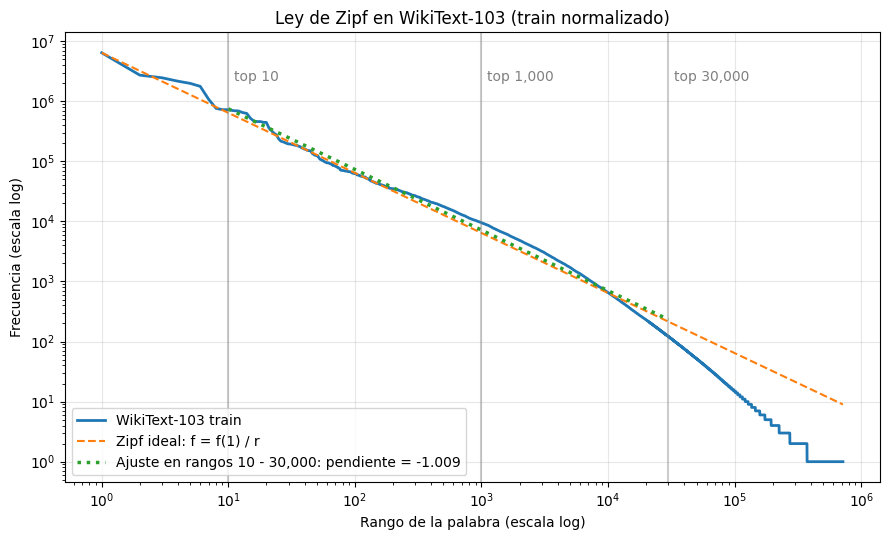

In [14]:
def pendiente_zipf(inicio, fin):
    """Pendiente en log-log entre dos rangos, con puntos espaciados logarítmicamente."""
    # Sin el muestreo logarítmico, los cientos de miles de palabras raras dominarían el ajuste
    indices = np.unique(np.geomspace(inicio, fin, 200).astype(int)) - 1
    pendiente, intercepto = np.polyfit(np.log10(rangos[indices]), np.log10(conteos_ordenados[indices]), 1)
    return pendiente, intercepto


tramos = {"1 - 1,000": (1, 1_000), "1,000 - 30,000": (1_000, 30_000),
          f"30,000 - {len(rangos):,}": (30_000, len(rangos)), "10 - 30,000 (ajuste)": (10, 30_000)}
for nombre, (inicio, fin) in tramos.items():
    print(f"Pendiente en rangos {nombre}: {pendiente_zipf(inicio, fin)[0]:.3f}")

pendiente, intercepto = pendiente_zipf(10, 30_000)
rangos_ajuste = rangos[9:30_000]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(rangos, conteos_ordenados, linewidth=2, label="WikiText-103 train")
ax.loglog(rangos, conteos_ordenados[0] / rangos, "--", label="Zipf ideal: f = f(1) / r")
ax.loglog(rangos_ajuste, 10 ** intercepto * rangos_ajuste ** pendiente, ":", linewidth=2.5,
          label=f"Ajuste en rangos 10 - 30,000: pendiente = {pendiente:.3f}")
for k in (10, 1_000, 30_000):
    ax.axvline(k, color="gray", alpha=0.4)
    ax.text(k * 1.1, conteos_ordenados[0] / 3, f"top {k:,}", color="gray")
ax.set_title("Ley de Zipf en WikiText-103 (train normalizado)")
ax.set_xlabel("Rango de la palabra (escala log)")
ax.set_ylabel("Frecuencia (escala log)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "zipf.png", dpi=150)
plt.show()

In [15]:
cobertura_acumulada = np.cumsum(conteos_ordenados) / total_tokens * 100

pd.DataFrame({
    "palabras_mas_frecuentes": [10, 1_000, 30_000],
    "tokens_cubiertos": [int(np.sum(conteos_ordenados[:k])) for k in (10, 1_000, 30_000)],
    "cobertura_%": [round(cobertura_acumulada[k - 1], 2) for k in (10, 1_000, 30_000)],
})

,palabras_mas_frecuentes,tokens_cubiertos,cobertura_%
0,10,20819540,24.61
1,1000,54155699,64.01
2,30000,80068586,94.64


**Construyan el vocabulario con un umbral de frecuencia mínima (min_count). ¿Qué tamaño de vocabulario y qué porcentaje de tokens desconocidos obtienen con al menos tres umbrales distintos?**

Sobre el train completo (84,607,547 tokens normalizados) se evaluaron seis umbrales. Con `min_count` de 3 se obtiene un vocabulario de 272,580 palabras y 0.643 % de tokens desconocidos, con 5 el vocabulario baja a 193,931 palabras con 0.958 %, con 10 a 127,797 con 1.469 % y con 100 a solo 33,804 palabras con 4.872 %. Es decir, al subir el umbral de 3 a 100 el vocabulario se reduce aproximadamente 8 veces mientras que los tokens desconocidos apenas pasan de 0.6 % a 4.9 %, ya que, como se observó con la ley de Zipf, las palabras raras son muchas pero representan una fracción muy pequeña del texto. No obstante, el costo se refleja en los benchmarks, ya que con un umbral de 100 se pierden 132 de las 905 palabras de las analogías, mientras que con 5 solo se pierden 15.

Cabe mencionar que, por restricciones de cómputo, para el resto del laboratorio se trabaja con un subconjunto formado por los primeros 6,801 artículos completos de train, que suman 20,008,141 tokens normalizados. Sobre este subconjunto se utiliza un `min_count` de 5, el valor por defecto de Word2Vec en gensim, con el que se obtiene un vocabulario de 87,487 palabras, 1.725 % de tokens desconocidos y 857 de las 905 palabras de las analogías. Dado que el subconjunto es aproximadamente 4.2 veces más pequeño que el corpus completo, este umbral se comporta de forma equivalente a un `min_count` de 20 sobre todo train, que produce un vocabulario de tamaño similar (86,126 palabras). Como limitación, el subconjunto corresponde a los primeros artículos del dataset y no a una muestra aleatoria.

In [19]:
UMBRALES_MIN_COUNT = [3, 5, 10, 20, 50, 100]

# Palabras de los benchmarks de selección, para ver cuántas sobreviven a cada umbral
palabras_analogias = {palabra.lower() for linea in lineas_analogias if not linea.startswith(":")
                      for palabra in linea.split()}
palabras_wordsim = set(df_wordsim["palabra_1"].str.lower()) | set(df_wordsim["palabra_2"].str.lower())

filas = []
for min_count in UMBRALES_MIN_COUNT:
    vocabulario = {palabra for palabra, n in frecuencias.items() if n >= min_count}
    tokens_unk = sum(n for palabra, n in frecuencias.items() if n < min_count)
    filas.append({
        "min_count": min_count,
        "tamano_vocabulario": len(vocabulario),
        "tokens_unk": tokens_unk,
        "porcentaje_unk": round(100 * tokens_unk / total_tokens, 3),
        "palabras_analogias": f"{len(palabras_analogias & vocabulario)}/{len(palabras_analogias)}",
        "palabras_wordsim": f"{len(palabras_wordsim & vocabulario)}/{len(palabras_wordsim)}",
    })

pd.DataFrame(filas)

,min_count,tamano_vocabulario,tokens_unk,porcentaje_unk,palabras_analogias,palabras_wordsim
0,3,272580,544261,0.643,897/905,437/437
1,5,193931,810620,0.958,890/905,437/437
2,10,127797,1242541,1.469,880/905,437/437
3,20,86126,1809455,2.139,865/905,437/437
4,50,51349,2893023,3.419,823/905,435/437
5,100,33804,4121662,4.872,773/905,424/437


**Implementen el submuestreo (subsampling) de palabras frecuentes de Word2Vec. ¿Qué porcentaje de las apariciones de "the", "of" y "and" se descarta? ¿Por qué ayuda al entrenamiento?**

Con la fórmula de submuestreo de gensim y el umbral por defecto `t = 1e-3` se descarta el 87.20 % de las apariciones de "the", el 79.28 % de "of" y el 78.02 % de "and", lo cual se verificó de forma empírica sobre 100,000 líneas de train, y aunque solo 25 palabras se ven afectadas, se elimina el 22.18 % de los tokens del corpus. Esto ayuda al entrenamiento ya que estas palabras aportan muy poco al significado de las que las rodean: saber que "king" aparece junto a "the" no dice nada sobre "king", puesto que "the" acompaña a prácticamente cualquier sustantivo. Es por esto que, al descartarlas, los pares de entrenamiento se concentran en palabras con contenido y el entrenamiento es más rápido, sin eliminarlas del vocabulario como ocurriría al quitar las stopwords.

In [20]:
UMBRALES_SUBMUESTREO = [1e-3, 1e-4, 1e-5]
PALABRAS_FRECUENTES = ["the", "of", "and"]
N_LINEAS_PRUEBA = 100_000


def probabilidad_conservar(frecuencias, total, t):
    """Probabilidad de conservar cada palabra con la fórmula de submuestreo de Word2Vec (versión de gensim)."""
    umbral = t * total
    return {palabra: min(1.0, (np.sqrt(n / umbral) + 1) * umbral / n) for palabra, n in frecuencias.items()}


def submuestrear(tokens, prob_conservar, rng):
    """Descarta cada aparición de una palabra con probabilidad 1 - P(conservar)."""
    return [token for token in tokens if rng.random() < prob_conservar.get(token, 1.0)]


filas = []
for t in UMBRALES_SUBMUESTREO:
    prob = probabilidad_conservar(frecuencias, total_tokens, t)
    fila = {"t": f"{t:.0e}"}
    for palabra in PALABRAS_FRECUENTES:
        fila[f"descarte_{palabra}_%"] = round(100 * (1 - prob[palabra]), 2)
    fila["descarte_total_%"] = round(100 * sum(n * (1 - prob[p]) for p, n in frecuencias.items()) / total_tokens, 2)
    fila["palabras_afectadas"] = sum(p < 1 for p in prob.values())
    filas.append(fila)
tabla_submuestreo = pd.DataFrame(filas)

# Verificación empírica de la implementación con t = 1e-3 en una muestra de train
rng = np.random.default_rng(SEED)
prob = probabilidad_conservar(frecuencias, total_tokens, 1e-3)
antes, despues = Counter(), Counter()
for linea in corpus["train"][:N_LINEAS_PRUEBA]["text"]:
    tokens = tokenizar(limpiar_wikitext(linea))
    antes.update(tokens)
    despues.update(submuestrear(tokens, prob, rng))
for palabra in PALABRAS_FRECUENTES:
    print(f"Descarte empírico de '{palabra}' con t = 1e-3: {100 * (1 - despues[palabra] / antes[palabra]):.2f} %")
print(f"Tokens de la muestra: {sum(antes.values()):,} -> {sum(despues.values()):,}")

tabla_submuestreo

Descarte empírico de 'the' con t = 1e-3: 87.20 %
Descarte empírico de 'of' con t = 1e-3: 79.29 %
Descarte empírico de 'and' con t = 1e-3: 77.99 %
Tokens de la muestra: 4,611,537 -> 3,588,776


,t,descarte_the_%,descarte_of_%,descarte_and_%,descarte_total_%,palabras_afectadas
0,1e-03,87.20,79.28,78.02,22.18,25
1,1e-04,96.24,94.12,93.79,39.19,373
2,1e-05,98.84,98.21,98.11,63.05,4031


## **Pipeline de preprocesamiento**

Con las decisiones anteriores se construye el pipeline completo sobre el subconjunto de entrenamiento: texto crudo -> `limpiar_wikitext` -> `tokenizar` -> vocabulario con `min_count` -> IDs. El corpus se guarda como un arreglo de IDs junto con el inicio de cada oración (`offsets`), de tal forma que las ventanas de contexto no crucen de un párrafo a otro.

In [23]:
RUTA_IDS = DIR_DATOS / "subconjunto_ids.npy"
RUTA_OFFSETS = DIR_DATOS / "subconjunto_offsets.npy"
RUTA_VOCABULARIO = DIR_DATOS / "vocabulario.json"
TOKENS_ESPECIALES = ["<pad>", "<unk>"]
ID_PAD, ID_UNK = 0, 1


def construir_subconjunto(lineas, tokens_minimos):
    """Tokeniza artículos completos de train hasta alcanzar el mínimo de tokens normalizados."""
    oraciones, total, articulos = [], 0, 0
    for i, linea in enumerate(lineas):
        es_titulo = (PATRON_TITULO.match(linea.rstrip("\n"))
                     and (i == 0 or lineas[i - 1] == "") and (i == len(lineas) - 1 or lineas[i + 1] == ""))
        if es_titulo:
            if total >= tokens_minimos:
                break
            articulos += 1
        tokens = tokenizar(limpiar_wikitext(linea))
        if tokens:
            oraciones.append(tokens)
            total += len(tokens)
    return oraciones, articulos


def construir_vocabulario(oraciones, min_count):
    """Vocabulario ordenado por frecuencia, con <pad> y <unk> al inicio."""
    conteo = Counter(token for oracion in oraciones for token in oracion)
    palabras = [palabra for palabra, n in conteo.most_common() if n >= min_count]
    conteos = [0, sum(n for n in conteo.values() if n < min_count)] + [conteo[p] for p in palabras]
    return TOKENS_ESPECIALES + palabras, conteos


if RUTA_IDS.exists() and RUTA_OFFSETS.exists() and RUTA_VOCABULARIO.exists():
    ids_corpus = np.load(RUTA_IDS)
    offsets = np.load(RUTA_OFFSETS)
    info_vocabulario = json.loads(RUTA_VOCABULARIO.read_text(encoding="utf-8"))
else:
    inicio = time.time()
    oraciones, n_articulos = construir_subconjunto(list(corpus["train"]["text"]), TOKENS_SUBCONJUNTO)
    itos, conteos = construir_vocabulario(oraciones, MIN_COUNT)
    stoi = {palabra: i for i, palabra in enumerate(itos)}
    ids_corpus = np.fromiter((stoi.get(t, ID_UNK) for oracion in oraciones for t in oracion), dtype=np.int32)
    offsets = np.cumsum([0] + [len(oracion) for oracion in oraciones], dtype=np.int64)
    info_vocabulario = {"itos": itos, "conteos": conteos, "articulos": n_articulos, "min_count": MIN_COUNT}
    np.save(RUTA_IDS, ids_corpus)
    np.save(RUTA_OFFSETS, offsets)
    RUTA_VOCABULARIO.write_text(json.dumps(info_vocabulario, ensure_ascii=False), encoding="utf-8")
    del oraciones
    print(f"Tiempo de construcción: {time.time() - inicio:.1f} s")

itos = info_vocabulario["itos"]
stoi = {palabra: i for i, palabra in enumerate(itos)}
conteos_vocabulario = np.array(info_vocabulario["conteos"], dtype=np.int64)

print(f"Artículos del subconjunto: {info_vocabulario['articulos']:,}")
print(f"Líneas (oraciones) con texto: {len(offsets) - 1:,}")
print(f"Tokens: {len(ids_corpus):,}")
print(f"Vocabulario con min_count = {MIN_COUNT}: {len(itos):,} (incluye {TOKENS_ESPECIALES})")
print(f"Tokens <unk>: {conteos_vocabulario[ID_UNK]:,} ({100 * conteos_vocabulario[ID_UNK] / len(ids_corpus):.3f} %)")
print(f"Ejemplo texto -> IDs: {itos[ids_corpus[0]]!r} -> {ids_corpus[0]}, primeras 10 IDs: {ids_corpus[:10].tolist()}")

Tiempo de construcción: 21.1 s
Artículos del subconjunto: 6,801
Líneas (oraciones) con texto: 203,995
Tokens: 20,008,141
Vocabulario con min_count = 5: 87,489 (incluye ['<pad>', '<unk>'])
Tokens <unk>: 345,198 (1.725 %)
Ejemplo texto -> IDs: 'senjō' -> 65686, primeras 10 IDs: [65686, 73, 20564, 156, 38088, 6424, 479, 1, 6294, 20564]


**Finalmente, generen los pares (palabra central, contexto) para skip-gram con una ventana de contexto y reporten cuántos pares de entrenamiento produce el corpus por epoch, antes y después del submuestreo.**

Los pares se generan con la función `generar_pares` utilizando una ventana de 5 palabras a cada lado, sin cruzar de un párrafo a otro y excluyendo los tokens `<unk>`, de la misma forma en que lo hace gensim. Por ejemplo, en la primera oración del subconjunto y con ventana de 2, la palabra "valkyria" genera cuatro pares, uno con cada una de las dos palabras anteriores y de las dos siguientes, como ("valkyria", "no"), ("valkyria", "3") y ("valkyria", "unrecorded"). Sobre el subconjunto de 19,662,943 tokens dentro del vocabulario, el corpus produce 190,611,304 pares por epoch antes del submuestreo, mientras que después de aplicarlo con `t = 1e-3` quedan 15,207,496 tokens y 146,067,686 pares, es decir, 23.37 % menos pares por epoch. Cabe mencionar que este conteo corresponde a una ventana fija, por lo que con la ventana dinámica que utiliza gensim por defecto el número real de pares sería menor.

In [24]:
def generar_pares(ids, ventana):
    """Genera los pares (central, contexto) de skip-gram de una oración con ventana fija."""
    pares = []
    for i, central in enumerate(ids):
        for j in range(max(0, i - ventana), min(len(ids), i + ventana + 1)):
            if j != i:
                pares.append((central, ids[j]))
    return pares


def contar_pares(longitudes, ventana):
    """Número exacto de pares con ventana fija para oraciones de las longitudes dadas."""
    n = longitudes.astype(np.int64)
    por_lado = np.where(n - 1 <= ventana, n * (n - 1) // 2,
                        ventana * (ventana + 1) // 2 + (n - 1 - ventana) * ventana)
    return int(2 * por_lado.sum())


def oraciones_filtradas(mascara):
    """Longitud de cada oración contando solo los tokens que cumplen la máscara."""
    return np.add.reduceat(mascara.astype(np.int64), offsets[:-1])


ejemplo = ids_corpus[offsets[0]:offsets[0] + 6].tolist()
print(f"Oración de ejemplo: {[itos[i] for i in ejemplo]}")
print(f"Pares con ventana 2: {[(itos[a], itos[b]) for a, b in generar_pares(ejemplo, 2)]}")

# Verificación de que el conteo con fórmula coincide con generar los pares uno por uno
n_verificacion = 1_000
pares_generados = sum(len(generar_pares(ids_corpus[offsets[k]:offsets[k + 1]].tolist(), VENTANA))
                      for k in range(n_verificacion))
pares_formula = contar_pares(np.diff(offsets[:n_verificacion + 1]), VENTANA)
print(f"Verificación en {n_verificacion:,} oraciones: generados = {pares_generados:,}, fórmula = {pares_formula:,}")

Oración de ejemplo: ['senjō', 'no', 'valkyria', '3', 'unrecorded', 'chronicles']
Pares con ventana 2: [('senjō', 'no'), ('senjō', 'valkyria'), ('no', 'senjō'), ('no', 'valkyria'), ('no', '3'), ('valkyria', 'senjō'), ('valkyria', 'no'), ('valkyria', '3'), ('valkyria', 'unrecorded'), ('3', 'no'), ('3', 'valkyria'), ('3', 'unrecorded'), ('3', 'chronicles'), ('unrecorded', 'valkyria'), ('unrecorded', '3'), ('unrecorded', 'chronicles'), ('chronicles', '3'), ('chronicles', 'unrecorded')]
Verificación en 1,000 oraciones: generados = 1,016,702, fórmula = 1,016,702


In [25]:
# Igual que gensim, las palabras bajo min_count (<unk>) no participan en los pares
total_vocabulario = conteos_vocabulario[len(TOKENS_ESPECIALES):].sum()
umbral = UMBRAL_SUBMUESTREO * total_vocabulario
frecuencia = np.maximum(conteos_vocabulario, 1)
prob_conservar_ids = np.minimum(1.0, (np.sqrt(frecuencia / umbral) + 1) * umbral / frecuencia)
prob_conservar_ids[:len(TOKENS_ESPECIALES)] = 0.0

mascara_vocabulario = ids_corpus != ID_UNK
rng = np.random.default_rng(SEED)
mascara_submuestreo = mascara_vocabulario & (rng.random(len(ids_corpus)) < prob_conservar_ids[ids_corpus])

escenarios = {
    "Antes del submuestreo (sin <unk>)": mascara_vocabulario,
    f"Después del submuestreo (t = {UMBRAL_SUBMUESTREO:.0e})": mascara_submuestreo,
}
filas = []
for nombre, mascara in escenarios.items():
    pares = contar_pares(oraciones_filtradas(mascara), VENTANA)
    filas.append({"escenario": nombre, "tokens": int(mascara.sum()), "pares_por_epoch": pares,
                  "pares_por_token": round(pares / mascara.sum(), 2)})
tabla_pares = pd.DataFrame(filas)
tabla_pares["reduccion_pares_%"] = (100 * (1 - tabla_pares["pares_por_epoch"] / tabla_pares["pares_por_epoch"].iloc[0])).round(2)
print(f"Ventana de contexto: {VENTANA}")
tabla_pares.style.format({"tokens": "{:,}", "pares_por_epoch": "{:,}"})

Ventana de contexto: 5


,escenario,tokens,pares_por_epoch,pares_por_token,reduccion_pares_%
0,Antes del submuestreo (sin ),"19,662,943","190,611,304",9.690000,0.000000
1,Después del submuestreo (t = 1e-03),"15,207,496","146,067,686",9.600000,23.370000


---
# **3. Investigación: embeddings en PyTorch y gensim**

---
# **4. Construcción y entrenamiento de los embeddings**

En esta sección se obtienen los tres conjuntos de embeddings: un skip-gram con negative sampling (SGNS) implementado desde cero en PyTorch, un Word2Vec de gensim entrenado con el mismo corpus, vocabulario e hiperparámetros equivalentes a la mejor configuración de SGNS, y GloVe preentrenado usado tal cual. Todos los modelos entrenados utilizan el subconjunto de 20M tokens y el vocabulario de la sección 2.

## **Skip-gram con negative sampling (PyTorch)**

En cada epoch se aplica un submuestreo nuevo y se generan los pares con ventana dinámica (cada palabra central usa una ventana aleatoria entre 1 y la ventana máxima), tal como lo hace gensim. Por cada par real se muestrean `negativos` palabras de una distribución proporcional a frecuencia^0.75. El modelo tiene dos tablas `nn.Embedding`: `entrada` (W) y `salida` (W'), y al final se conserva W.

In [28]:
import torch.nn.functional as F

oracion_de_token = np.repeat(np.arange(len(offsets) - 1), np.diff(offsets))

# Tabla de muestreo de negativos con probabilidad proporcional a frecuencia^0.75, como en Word2Vec
peso_unigrama = conteos_vocabulario.astype(np.float64) ** 0.75
peso_unigrama[:len(TOKENS_ESPECIALES)] = 0
rng_tabla = np.random.default_rng(SEED)
tabla_negativos = torch.from_numpy(
    np.searchsorted(np.cumsum(peso_unigrama / peso_unigrama.sum()), rng_tabla.random(10_000_000))
).to(DEVICE)


def generar_pares_epoch(n_tokens, ventana, umbral, rng):
    """Submuestrea el corpus y genera los pares de una epoch con ventana dinámica, igual que gensim."""
    ids, oraciones = ids_corpus[:n_tokens], oracion_de_token[:n_tokens]
    conteos = np.bincount(ids, minlength=len(itos))
    umbral_absoluto = umbral * conteos[len(TOKENS_ESPECIALES):].sum()
    frecuencia = np.maximum(conteos, 1)
    prob = np.minimum(1.0, (np.sqrt(frecuencia / umbral_absoluto) + 1) * umbral_absoluto / frecuencia)
    prob[:len(TOKENS_ESPECIALES)] = 0.0  # <unk> nunca participa

    mascara = rng.random(n_tokens) < prob[ids]
    tokens, oracion = ids[mascara], oraciones[mascara]
    # Cada palabra central usa una ventana aleatoria entre 1 y la ventana máxima
    ventana_efectiva = rng.integers(1, ventana + 1, size=len(tokens))
    centros, contextos = [], []
    for d in range(1, ventana + 1):
        i = np.arange(len(tokens) - d)
        j = i + d
        misma_oracion = oracion[i] == oracion[j]
        hacia_derecha = misma_oracion & (ventana_efectiva[i] >= d)
        hacia_izquierda = misma_oracion & (ventana_efectiva[j] >= d)
        centros += [tokens[i[hacia_derecha]], tokens[j[hacia_izquierda]]]
        contextos += [tokens[j[hacia_derecha]], tokens[i[hacia_izquierda]]]
    centros, contextos = np.concatenate(centros), np.concatenate(contextos)
    orden = rng.permutation(len(centros))
    return torch.from_numpy(centros[orden]), torch.from_numpy(contextos[orden])


class SkipGramNS(nn.Module):
    """Skip-gram con negative sampling: tabla de entrada W y tabla de salida W'."""

    def __init__(self, n_palabras, dim):
        super().__init__()
        self.entrada = nn.Embedding(n_palabras, dim)
        self.salida = nn.Embedding(n_palabras, dim)
        # Misma inicialización que word2vec: W pequeña y aleatoria, W' en ceros
        nn.init.uniform_(self.entrada.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.salida.weight)

    def forward(self, centros, contextos, negativos):
        v = self.entrada(centros)
        positivo = F.logsigmoid((v * self.salida(contextos)).sum(dim=1))
        negativo = F.logsigmoid(-torch.bmm(self.salida(negativos), v.unsqueeze(2)).squeeze(2)).sum(dim=1)
        return -(positivo + negativo).mean()


centros_prueba, contextos_prueba = generar_pares_epoch(len(ids_corpus), VENTANA, UMBRAL_SUBMUESTREO, np.random.default_rng(SEED))
print(f"Pares de una epoch con ventana dinámica: {len(centros_prueba):,}")
print(f"Ejemplos: {[(itos[c], itos[x]) for c, x in zip(centros_prueba[:5].tolist(), contextos_prueba[:5].tolist())]}")
modelo_prueba = SkipGramNS(len(itos), DIM_BASE)
print(f"Parámetros con dim = {DIM_BASE}: {sum(p.numel() for p in modelo_prueba.parameters()):,}")
del centros_prueba, contextos_prueba, modelo_prueba

Pares de una epoch con ventana dinámica: 88,439,229
Ejemplos: [('street', 'canal'), ('he', 'his'), ('scheduled', 'september'), ('salford', 'industrialisation'), ('1942', 'contained')]
Parámetros con dim = 100: 17,497,800


Al final de cada epoch se evalúan las analogías de `questions-words.txt` restringidas a las 30,000 palabras más frecuentes del modelo (semánticas, sintácticas y total), la correlación de Spearman en WordSim-353 y los 5 vecinos más cercanos de las palabras de control. SimLex-999 no se usa aquí, ya que se reserva para la evaluación final.

In [29]:
from gensim.models import KeyedVectors


def a_keyedvectors(palabras, vectores):
    """Envuelve una matriz de embeddings en KeyedVectors para usar las evaluaciones de gensim."""
    kv = KeyedVectors(vectores.shape[1])
    kv.add_vectors(palabras, vectores)
    return kv


def evaluar_embeddings(kv):
    """Analogías (semánticas, sintácticas y total), Spearman en WordSim-353 y vecinos de control."""
    _, secciones = kv.evaluate_word_analogies(analogias, restrict_vocab=VOCAB_EVALUACION)
    conteo = {"semanticas": [0, 0], "sintacticas": [0, 0]}
    for seccion in secciones[:-1]:
        tipo = "sintacticas" if seccion["section"].startswith("gram") else "semanticas"
        conteo[tipo][0] += len(seccion["correct"])
        conteo[tipo][1] += len(seccion["correct"]) + len(seccion["incorrect"])
    total = secciones[-1]
    evaluadas = len(total["correct"]) + len(total["incorrect"])
    return {
        "analogias_semanticas": conteo["semanticas"][0] / conteo["semanticas"][1],
        "analogias_sintacticas": conteo["sintacticas"][0] / conteo["sintacticas"][1],
        "analogias_total": len(total["correct"]) / evaluadas,
        "analogias_evaluadas": evaluadas,
        "wordsim_spearman": float(kv.evaluate_word_pairs(wordsim)[1][0]),
        "vecinos": {p: [w for w, _ in kv.most_similar(p, topn=5)] if p in kv else [] for p in PALABRAS_CONTROL},
    }


def sincronizar():
    """Espera a que la GPU termine para medir tiempos reales."""
    if DEVICE.type == "mps":
        torch.mps.synchronize()


def memoria_gpu():
    """Memoria asignada en la GPU en bytes (MPS no tiene max_memory_allocated)."""
    return torch.mps.current_allocated_memory() if DEVICE.type == "mps" else 0

La función de entrenamiento es reanudable: cada iteración guarda su registro (configuración, historial por epoch, tiempos y memoria) en `resultados/iteraciones_sgns/` y la matriz W en `modelos/`. Si una iteración ya existe, se carga en lugar de reentrenarse.

In [30]:
DIR_ITERACIONES = DIR_RESULTADOS / "iteraciones_sgns"
DIR_ITERACIONES.mkdir(exist_ok=True)


def entrenar_sgns(nombre, config):
    """Entrena una iteración de SGNS y guarda su registro; si ya existe, solo lo carga."""
    ruta_registro = DIR_ITERACIONES / f"{nombre}.json"
    ruta_pesos = DIR_MODELOS / f"sgns_{nombre}.npy"
    if ruta_registro.exists() and ruta_pesos.exists():
        print(f"[{nombre}] ya entrenada, se carga del registro")
        return json.loads(ruta_registro.read_text(encoding="utf-8"))

    fijar_semilla()
    rng = np.random.default_rng(SEED)
    # La fracción del corpus se toma en oraciones completas
    n_tokens = int(offsets[round(config["fraccion_corpus"] * (len(offsets) - 1))])
    tokens_corpus = int(np.count_nonzero(ids_corpus[:n_tokens] != ID_UNK))
    modelo = SkipGramNS(len(itos), config["dim"]).to(DEVICE)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=config["learning_rate"])
    print(f"[{nombre}] {config} | tokens: {tokens_corpus:,}")

    historial, memoria_pico = [], memoria_gpu()
    inicio_total = time.time()
    for epoch in range(1, config["epochs"] + 1):
        inicio = time.time()
        centros, contextos = generar_pares_epoch(n_tokens, config["ventana"], config["umbral_submuestreo"], rng)
        suma_perdida = torch.zeros((), device=DEVICE)
        perdidas_cada_n = []
        n_pasos = 0
        for k in range(0, len(centros), config["batch_size"]):
            c = centros[k:k + config["batch_size"]].to(DEVICE)
            x = contextos[k:k + config["batch_size"]].to(DEVICE)
            negativos = tabla_negativos[torch.randint(len(tabla_negativos), (len(c), config["negativos"]), device=DEVICE)]
            perdida = modelo(c, x, negativos)
            optimizador.zero_grad(set_to_none=True)
            perdida.backward()
            optimizador.step()
            suma_perdida += perdida.detach()
            if n_pasos % PASOS_REGISTRO == 0:
                perdidas_cada_n.append(perdida.item())
                memoria_pico = max(memoria_pico, memoria_gpu())
            n_pasos += 1
        sincronizar()
        tiempo_epoch = time.time() - inicio

        inicio_evaluacion = time.time()
        vectores = modelo.entrada.weight.detach().cpu().numpy()
        metricas = evaluar_embeddings(a_keyedvectors(itos[len(TOKENS_ESPECIALES):], vectores[len(TOKENS_ESPECIALES):]))
        historial.append({
            "epoch": epoch, "perdida": suma_perdida.item() / n_pasos, "perdidas_cada_n_pasos": perdidas_cada_n,
            "pares": len(centros), "pasos": n_pasos, "tiempo_epoch_s": tiempo_epoch,
            "tiempo_evaluacion_s": time.time() - inicio_evaluacion, **metricas,
        })
        print(f"[{nombre}] epoch {epoch}: pérdida {historial[-1]['perdida']:.4f}, "
              f"analogías {metricas['analogias_total']:.4f} (sem {metricas['analogias_semanticas']:.4f}, "
              f"sin {metricas['analogias_sintacticas']:.4f}), WordSim {metricas['wordsim_spearman']:.4f}, "
              f"{tiempo_epoch:.1f} s")
        del centros, contextos

    registro = {
        "nombre": nombre, "config": config, "tokens_corpus": tokens_corpus, "vocabulario": len(itos),
        "parametros": sum(p.numel() for p in modelo.parameters()), "historial": historial,
        "tiempo_total_s": time.time() - inicio_total,
        "tiempo_entrenamiento_s": sum(h["tiempo_epoch_s"] for h in historial),
        "memoria_pico_gb": memoria_pico / 1e9, "dispositivo": str(DEVICE),
    }
    np.save(ruta_pesos, vectores)
    ruta_registro.write_text(json.dumps(registro, ensure_ascii=False, indent=1), encoding="utf-8")
    del modelo, optimizador
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    return registro

## **Iteraciones de SGNS**

Cada iteración cambia un único hiperparámetro respecto a la configuración base (dim 100, ventana 5, 5 negativos, submuestreo 1e-3, `min_count` 5, 100 % del subconjunto, 5 epochs, Adam con learning rate 2e-3 y batch de 32,768 pares). El tiempo estimado total es de aproximadamente 1.5 horas en MPS; si se interrumpe, al volver a ejecutar la celda continúa desde la siguiente iteración pendiente.

In [31]:
CONFIG_BASE = {
    "dim": DIM_BASE, "ventana": VENTANA, "negativos": NEGATIVOS, "umbral_submuestreo": UMBRAL_SUBMUESTREO,
    "min_count": MIN_COUNT, "fraccion_corpus": 1.0, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
}
# Cada iteración cambia un solo hiperparámetro respecto a la base
ITERACIONES = {
    "base": {},
    "dim_50": {"dim": 50},
    "dim_300": {"dim": 300},
    "corpus_25": {"fraccion_corpus": 0.25},
    "corpus_50": {"fraccion_corpus": 0.5},
    "ventana_2": {"ventana": 2},
    "ventana_10": {"ventana": 10},
    "negativos_15": {"negativos": 15},
    "submuestreo_1e-4": {"umbral_submuestreo": 1e-4},
}

registro_sgns = {nombre: entrenar_sgns(nombre, {**CONFIG_BASE, **cambios}) for nombre, cambios in ITERACIONES.items()}

[base] {'dim': 100, 'ventana': 5, 'negativos': 5, 'umbral_submuestreo': 0.001, 'min_count': 5, 'fraccion_corpus': 1.0, 'epochs': 5, 'batch_size': 32768, 'learning_rate': 0.002} | tokens: 19,662,943
[base] epoch 1: pérdida 2.4541, analogías 0.1659 (sem 0.1142, sin 0.1897), WordSim 0.5544, 96.5 s
[base] epoch 2: pérdida 2.2662, analogías 0.3050 (sem 0.1957, sin 0.3551), WordSim 0.6140, 98.1 s
[base] epoch 3: pérdida 2.2288, analogías 0.3559 (sem 0.2482, sin 0.4053), WordSim 0.6344, 98.1 s
[base] epoch 4: pérdida 2.2115, analogías 0.3784 (sem 0.2830, sin 0.4222), WordSim 0.6463, 99.1 s
[base] epoch 5: pérdida 2.2011, analogías 0.3866 (sem 0.3043, sin 0.4244), WordSim 0.6455, 99.5 s
[dim_50] {'dim': 50, 'ventana': 5, 'negativos': 5, 'umbral_submuestreo': 0.001, 'min_count': 5, 'fraccion_corpus': 1.0, 'epochs': 5, 'batch_size': 32768, 'learning_rate': 0.002} | tokens: 19,662,943
[dim_50] epoch 1: pérdida 2.5035, analogías 0.0936 (sem 0.0759, sin 0.1018), WordSim 0.5019, 55.8 s
[dim_50] epoc

In [32]:
filas = []
for nombre, r in registro_sgns.items():
    final = r["historial"][-1]
    filas.append({
        "iteracion": nombre, "dim": r["config"]["dim"], "ventana": r["config"]["ventana"],
        "negativos": r["config"]["negativos"], "submuestreo": r["config"]["umbral_submuestreo"],
        "tokens_corpus": r["tokens_corpus"], "perdida_final": round(final["perdida"], 4),
        "analogias_sem": round(final["analogias_semanticas"], 4), "analogias_sin": round(final["analogias_sintacticas"], 4),
        "analogias_total": round(final["analogias_total"], 4), "wordsim": round(final["wordsim_spearman"], 4),
        "tiempo_epoch_min": round(np.mean([h["tiempo_epoch_s"] for h in r["historial"]]) / 60, 2),
        "tiempo_total_min": round(r["tiempo_total_s"] / 60, 2), "memoria_pico_gb": round(r["memoria_pico_gb"], 2),
    })
tabla_iteraciones = pd.DataFrame(filas).set_index("iteracion")

# Selección por las métricas de validación (analogías y WordSim), nunca por SimLex
MEJOR_SGNS = tabla_iteraciones.sort_values(["analogias_total", "wordsim"], ascending=False).index[0]
print(f"Mejor iteración: {MEJOR_SGNS}")
tabla_iteraciones

Mejor iteración: dim_300


,dim,ventana,negativos,submuestreo,tokens_corpus,perdida_final,analogias_sem,analogias_sin,analogias_total,wordsim,tiempo_epoch_min,tiempo_total_min,memoria_pico_gb
iteracion,,,,,,,,,,,,,
base,100,5,5,0.0010,19662943,2.2011,0.3043,0.4244,0.3866,0.6455,1.64,8.51,0.37
dim_50,50,5,5,0.0010,19662943,2.2453,0.2057,0.3227,0.2859,0.6156,0.95,5.00,0.23
dim_300,300,5,5,0.0010,19662943,2.1290,0.4246,0.4808,0.4631,0.6836,4.46,23.43,0.94
corpus_25,100,5,5,0.0010,4875402,2.1848,0.0805,0.1616,0.1361,0.5069,0.38,2.29,0.37
corpus_50,100,5,5,0.0010,9855057,2.1839,0.1906,0.3121,0.2739,0.6199,0.77,4.18,0.37
ventana_2,100,2,5,0.0010,19662943,2.0527,0.2380,0.4078,0.3544,0.6086,0.75,4.11,0.37
ventana_10,100,10,5,0.0010,19662943,2.2710,0.3489,0.4178,0.3962,0.6560,2.84,14.56,0.37
negativos_15,100,5,15,0.0010,19662943,3.1368,0.3463,0.4627,0.4261,0.6195,3.65,18.66,0.37
submuestreo_1e-4,100,5,5,0.0001,19662943,2.1563,0.3191,0.4272,0.3932,0.6676,1.53,8.07,0.37


In [33]:
def vecinos_por_epoch(nombre):
    """Tabla con los 5 vecinos más cercanos de cada palabra de control al final de cada epoch."""
    historial = registro_sgns[nombre]["historial"]
    return pd.DataFrame({f"epoch {h['epoch']}": {p: ", ".join(v) for p, v in h["vecinos"].items()} for h in historial})


vecinos_por_epoch(MEJOR_SGNS)

,epoch 1,epoch 2,epoch 3,epoch 4,epoch 5
king,"kalachuri, henry, mbó, dagobert, pope","maíl, mbó, diarmait, murchad, æthelred","maíl, mbó, diarmait, queen, sennacherib","maíl, ballala, mbó, sennacherib, monarch","maíl, mbó, monarch, queen, diarmait"
france,"spain, italy, portugal, belgium, netherlands","spain, italy, portugal, netherlands, belgium","italy, spain, portugal, belgium, austria","spain, italy, germany, belgium, austria","spain, italy, germany, belgium, austria"
computer,"computers, desktop, software, multi-core, computing","computers, desktop, pdp-1, havok, software","computers, desktop, real-time, pdp-1, software","computers, software, desktop, multi-core, pdp-1","computers, multi-core, mainframe, software, real-time"
good,"bad, decent, craved, nice, wonderful","bad, excellent, poor, decent, nice","bad, excellent, better, poor, pretty","bad, excellent, poor, better, pretty","bad, excellent, better, poor, luck"
january,"february, december, november, march, july","february, december, march, november, july","february, december, march, october, july","february, march, december, november, october","february, december, march, october, november"
run,"pinch-hit, 76-yard, three-run, walk-off, inside-the-park","inside-the-park, runs, three-run, game-tying, running","runs, running, inside-the-park, ran, eighth-inning","runs, running, inside-the-park, eighth-inning, ran","running, runs, inside-the-park, ran, three-run"


**Grafiquen las curvas de pérdida y de accuracy de analogías por epoch de al menos 3 iteraciones. ¿Una pérdida más baja implica siempre mejores embeddings?**

No. Un embedding es la representación de una palabra como un vector denso, de tal forma que palabras que aparecen en contextos similares queden cerca en el espacio, mientras que la pérdida de SGNS mide únicamente qué tan bien el modelo distingue los pares (palabra central, contexto) reales de los pares formados con palabras negativas al azar, por lo que evalúa la tarea de entrenamiento y no la calidad del significado capturado. Esto se observa al contrastar las iteraciones: `corpus_25` obtuvo una pérdida de 2.185, menor a la de la base (2.201), pero solo 13.61 % de accuracy en analogías, ya que con 4.9M tokens el modelo aprende a separar los mismos pares sin capturar relaciones generales, y `ventana_2` alcanzó la pérdida más baja (2.053) al predecir únicamente vecinos inmediatos, pero su accuracy (35.44 %) quedó por debajo del de la base (38.66 %). En cambio, `negativos_15` tuvo la pérdida más alta (3.137) y el segundo mejor accuracy (42.61 %), aunque cabe mencionar que su pérdida suma 15 términos negativos en lugar de 5. Es por esto que la pérdida solo resulta útil para monitorear la convergencia dentro de una misma iteración, donde las curvas muestran que baja mientras el accuracy sube, pero no para comparar configuraciones distintas.

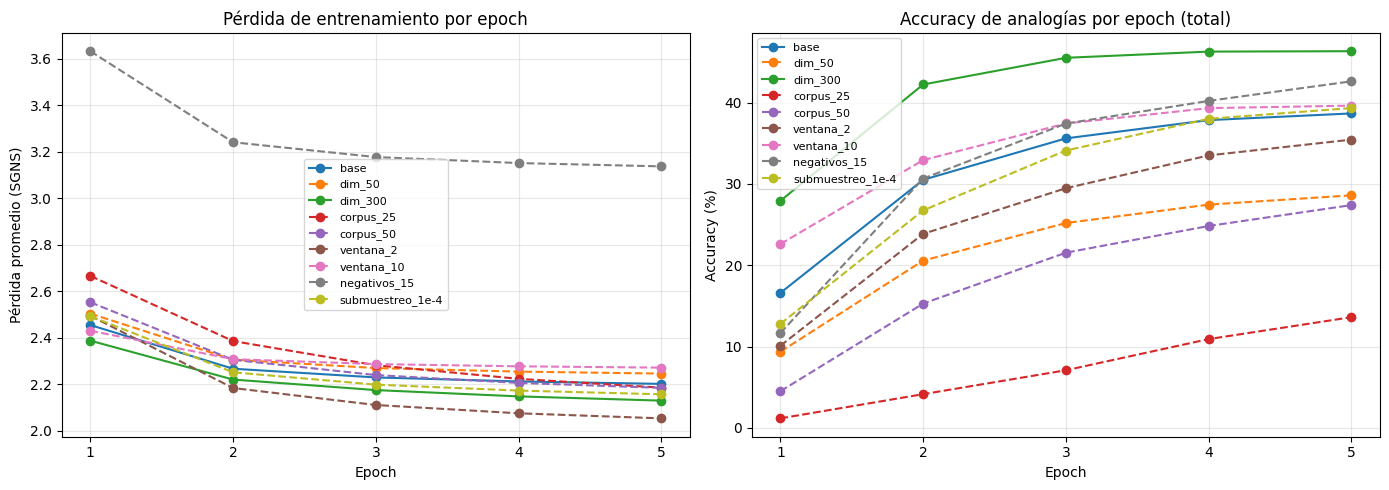

In [35]:
fig, (ax_perdida, ax_analogias) = plt.subplots(1, 2, figsize=(14, 5))
for nombre, r in registro_sgns.items():
    epochs = [h["epoch"] for h in r["historial"]]
    estilo = "-" if nombre in ("base", MEJOR_SGNS) else "--"
    ax_perdida.plot(epochs, [h["perdida"] for h in r["historial"]], estilo, marker="o", label=nombre)
    ax_analogias.plot(epochs, [100 * h["analogias_total"] for h in r["historial"]], estilo, marker="o", label=nombre)
ax_perdida.set_title("Pérdida de entrenamiento por epoch")
ax_perdida.set_xlabel("Epoch")
ax_perdida.set_ylabel("Pérdida promedio (SGNS)")
ax_analogias.set_title("Accuracy de analogías por epoch (total)")
ax_analogias.set_xlabel("Epoch")
ax_analogias.set_ylabel("Accuracy (%)")
for ax in (ax_perdida, ax_analogias):
    ax.set_xticks(range(1, EPOCHS + 1))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "curvas_sgns.png", dpi=150)
plt.show()

## **Word2Vec de gensim**

Como implementación de referencia se entrena `Word2Vec` de gensim en modo skip-gram (`sg=1`) con negative sampling, sobre exactamente las mismas oraciones del subconjunto y con los hiperparámetros de la mejor iteración de SGNS. Con `min_count` igual, gensim construye el mismo vocabulario de 87,487 palabras. La diferencia principal es el optimizador: gensim usa SGD par por par con un learning rate que decae linealmente de 0.025 a 0.0001 y corre en CPU, mientras que nuestro SGNS usa Adam en batches de 32,768 pares en MPS. Cabe mencionar que con Python 3.13 gensim imprime ocasionalmente el aviso `Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'`; no corresponde a una excepción real de Python y aparece aproximadamente una docena de veces por epoch, frente a cerca de 88M pares, por lo que su efecto es despreciable.

In [38]:
import os

from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

RUTA_GENSIM_KV = DIR_MODELOS / "gensim_word2vec.kv"
RUTA_GENSIM_REGISTRO = DIR_RESULTADOS / "gensim_word2vec.json"
config_mejor = registro_sgns[MEJOR_SGNS]["config"]


class RegistroPorEpoch(CallbackAny2Vec):
    """Registra pérdida, tiempo y métricas de evaluación al final de cada epoch de gensim."""

    def __init__(self):
        self.historial, self.epoch, self.perdida_acumulada = [], 0, 0.0
        self.inicio = time.time()

    def on_epoch_end(self, modelo):
        self.epoch += 1
        tiempo_epoch = time.time() - self.inicio
        # gensim reporta la pérdida acumulada, por lo que se resta la de la epoch anterior
        perdida_total = modelo.get_latest_training_loss()
        perdida_epoch, self.perdida_acumulada = perdida_total - self.perdida_acumulada, perdida_total
        # gensim guarda en caché las normas de los vectores; sin recalcularlas, most_similar usaría las de la epoch 1
        modelo.wv.fill_norms(force=True)
        metricas = evaluar_embeddings(modelo.wv)
        self.historial.append({"epoch": self.epoch, "perdida_gensim": perdida_epoch, "tiempo_epoch_s": tiempo_epoch, **metricas})
        print(f"[gensim] epoch {self.epoch}: analogías {metricas['analogias_total']:.4f} "
              f"(sem {metricas['analogias_semanticas']:.4f}, sin {metricas['analogias_sintacticas']:.4f}), "
              f"WordSim {metricas['wordsim_spearman']:.4f}, {tiempo_epoch:.1f} s")
        self.inicio = time.time()


if RUTA_GENSIM_KV.exists() and RUTA_GENSIM_REGISTRO.exists():
    vectores_gensim = KeyedVectors.load(str(RUTA_GENSIM_KV))
    registro_gensim = json.loads(RUTA_GENSIM_REGISTRO.read_text(encoding="utf-8"))
    print("Word2Vec de gensim ya entrenado, se carga del registro")
else:
    # Mismo corpus que SGNS: las oraciones del subconjunto sin los <unk>, que gensim descartaría igual
    oraciones_gensim = [[itos[i] for i in ids_corpus[a:b] if i != ID_UNK] for a, b in zip(offsets[:-1], offsets[1:])]
    callback = RegistroPorEpoch()
    inicio = time.time()
    modelo_gensim = Word2Vec(
        sentences=oraciones_gensim, sg=1, hs=0, vector_size=config_mejor["dim"], window=config_mejor["ventana"],
        negative=config_mejor["negativos"], sample=config_mejor["umbral_submuestreo"], min_count=config_mejor["min_count"],
        epochs=config_mejor["epochs"], workers=os.cpu_count(), seed=SEED, compute_loss=True, callbacks=[callback],
    )
    vectores_gensim = modelo_gensim.wv
    registro_gensim = {
        "config": {**config_mejor, "sg": 1, "alpha": modelo_gensim.alpha, "min_alpha": modelo_gensim.min_alpha,
                   "workers": os.cpu_count()},
        "tokens_corpus": modelo_gensim.corpus_total_words, "vocabulario": len(vectores_gensim),
        "historial": callback.historial, "tiempo_total_s": time.time() - inicio, "dispositivo": "cpu",
    }
    vectores_gensim.save(str(RUTA_GENSIM_KV))
    RUTA_GENSIM_REGISTRO.write_text(json.dumps(registro_gensim, ensure_ascii=False, indent=1), encoding="utf-8")
    del oraciones_gensim, modelo_gensim

print(f"Vocabulario gensim: {registro_gensim['vocabulario']:,} | SGNS: {len(itos) - len(TOKENS_ESPECIALES):,}")
print(f"Tokens del corpus: {registro_gensim['tokens_corpus']:,} | Tiempo total: {registro_gensim['tiempo_total_s'] / 60:.1f} min")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

[gensim] epoch 1: analogías 0.1234 (sem 0.0636, sin 0.1494), WordSim 0.5065, 24.9 s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

[gensim] epoch 2: analogías 0.2258 (sem 0.1289, sin 0.2680), WordSim 0.5804, 26.0 s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[gensim] epoch 3: analogías 0.3130 (sem 0.1818, sin 0.3701), WordSim 0.6229, 31.6 s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[gensim] epoch 4: analogías 0.3636 (sem 0.2266, sin 0.4232), WordSim 0.6389, 26.8 s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

[gensim] epoch 5: analogías 0.3939 (sem 0.2630, sin 0.4508), WordSim 0.6422, 30.3 s
Vocabulario gensim: 87,487 | SGNS: 87,487
Tokens del corpus: 19,662,943 | Tiempo total: 3.5 min


## **GloVe preentrenado**

GloVe (`glove-wiki-gigaword-100`) se utiliza tal cual, sin entrenamiento adicional, y se evalúa con las mismas métricas. Al final se resume el estado de los tres conjuntos de embeddings. Cabe mencionar que el número de analogías evaluadas difiere entre modelos, ya que cada uno usa sus propias 30,000 palabras más frecuentes; la comparación con un vocabulario compartido se realiza en la sección 5.

In [39]:
RUTA_GLOVE_REGISTRO = DIR_RESULTADOS / "glove.json"

# GloVe se usa tal cual: no se entrena, solo se evalúa con las mismas métricas
if RUTA_GLOVE_REGISTRO.exists():
    registro_glove = json.loads(RUTA_GLOVE_REGISTRO.read_text(encoding="utf-8"))
else:
    registro_glove = {
        "modelo": "glove-wiki-gigaword-100", "tokens_corpus": 6_000_000_000, "vocabulario": len(glove),
        "dim": glove.vector_size, **evaluar_embeddings(glove),
    }
    RUTA_GLOVE_REGISTRO.write_text(json.dumps(registro_glove, ensure_ascii=False, indent=1), encoding="utf-8")

# Vectores del mejor SGNS en formato KeyedVectors para las secciones siguientes
RUTA_SGNS_KV = DIR_MODELOS / "sgns_mejor.kv"
vectores_sgns = a_keyedvectors(itos[len(TOKENS_ESPECIALES):],
                               np.load(DIR_MODELOS / f"sgns_{MEJOR_SGNS}.npy")[len(TOKENS_ESPECIALES):])
vectores_sgns.save(str(RUTA_SGNS_KV))

final_sgns = registro_sgns[MEJOR_SGNS]["historial"][-1]
final_gensim = registro_gensim["historial"][-1]
resumen = {
    f"SGNS ({MEJOR_SGNS})": (registro_sgns[MEJOR_SGNS]["tokens_corpus"], len(vectores_sgns), vectores_sgns.vector_size, final_sgns),
    "Word2Vec gensim": (registro_gensim["tokens_corpus"], registro_gensim["vocabulario"], vectores_gensim.vector_size, final_gensim),
    "GloVe": (registro_glove["tokens_corpus"], registro_glove["vocabulario"], registro_glove["dim"], registro_glove),
}
tabla_tres_modelos = pd.DataFrame({
    nombre: {
        "tokens_corpus": f"{tokens:,}", "vocabulario": f"{vocab:,}", "dim": dim,
        "analogias_sem_%": round(100 * m["analogias_semanticas"], 2), "analogias_sin_%": round(100 * m["analogias_sintacticas"], 2),
        "analogias_total_%": round(100 * m["analogias_total"], 2), "analogias_evaluadas": m["analogias_evaluadas"],
        "wordsim_spearman": round(m["wordsim_spearman"], 4),
    }
    for nombre, (tokens, vocab, dim, m) in resumen.items()
}).T
tabla_tres_modelos

,tokens_corpus,vocabulario,dim,analogias_sem_%,analogias_sin_%,analogias_total_%,analogias_evaluadas,wordsim_spearman
SGNS (dim_300),"19,662,943","87,487",300,42.46,48.08,46.31,11801,0.6836
Word2Vec gensim,"19,662,943","87,487",300,26.3,45.08,39.39,11775,0.6422
GloVe,"6,000,000,000","400,000",100,65.54,65.45,65.49,14877,0.5327


## **Sinopsis de resultados**

Para evaluar los embeddings se utilizaron dos métricas. El accuracy de analogías mide el porcentaje de preguntas del tipo "a es a b como c es a d" en las que la palabra más cercana a `b - a + c` es exactamente `d`, y se separa en semánticas (conocimiento del mundo, como país-capital o relaciones familiares) y sintácticas (relaciones gramaticales, como plurales, comparativos o tiempos verbales). Por su parte, la correlación de Spearman en WordSim-353 mide qué tanto coincide el orden de similitud coseno del modelo con el orden que asignaron personas a 353 pares de palabras. Con la misma configuración (dimensión 300, ventana 5 y 5 negativos), nuestro SGNS obtuvo 46.31 % de accuracy total y 0.684 en WordSim, superando al Word2Vec de gensim (39.39 % y 0.642) principalmente en las analogías semánticas (42.46 % frente a 26.30 %), mientras que en las sintácticas ambos obtienen resultados similares (48.08 % y 45.08 %). Por otro lado, GloVe alcanzó 65.49 % en analogías gracias a sus 6 mil millones de tokens de entrenamiento, aproximadamente 300 veces más que nuestro subconjunto, aunque obtuvo la correlación más baja en WordSim (0.533). Cabe mencionar que el número de analogías evaluadas difiere entre modelos (11,801, 11,775 y 14,877), ya que cada uno usa sus propias 30,000 palabras más frecuentes, por lo que la comparación con un vocabulario compartido se realiza en la sección 5.

---
# **5. Verificación de la aritmética vectorial**

---
# **6. Pipeline end-to-end: clasificación de texto**

---
# **7. Comparación de resultados**

---
# **8. Discusión y análisis**